In [1]:
# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

In [ ]:
os.chdir("/llm_coding/")

In [ ]:
# Set directories
#upload 3 dataset that created by ChatGPT responses and name them as df1, df2, and df3. 
home_dir = "/llm_coding/"
df1_path = os.path.join(home_dir, "I_tst.csv")  # The I revision path
df2_path = os.path.join(home_dir, "II_tst.csv")  # The II revision path
df3_path = os.path.join(home_dir, "III_tst.csv")  # The III revision path
neg_path = os.path.join(home_dir, "hiv_msgs_working_20241118.csv")


# Read CSV files
df1 = pd.read_csv(df1_path)
df2 = pd.read_csv(df2_path)
df3 = pd.read_csv(df3_path)
neg_df = pd.read_csv(neg_path)

In [4]:
df3.head(3)

,Unnamed: 0,index,sub_id,q_info_sti_tst,q_info_sti_prev,q_info_sti_care,q_inst_sti_tst,q_inst_sti_prev,q_inst_sti_falseprev,q_inst_sti_care,...,inst_sti_care_ans,inst_sti_care_rsn,negt_sti_tst_ans,negt_sti_tst_rsn,negt_pub_hlt_ans,negt_pub_hlt_rsn,if_sti_ans,if_sti_rsn,whic_sti_ans,whic_sti_rsn
0,0,0,actionable_0,No | The text only mentions a condom machine a...,No | The text only mentions a condom machine a...,No | The text mentions a condom machine in rel...,No | The text mentions condom machines but doe...,Yes | The text suggests that a condom machine ...,Yes | The text suggests that the availability ...,No | The text does not encourage or promote be...,...,No,The text does not encourage or promote behavi...,No,The text suggests the use of a condom machine...,No,The text suggests a pragmatic solution to pre...,Yes,"The mention of ""aids"" indicates a direct refe...",Yes,"The text mentions ""aids,"" which refers to Acq..."
1,1,0,actionable_1,No | The text does not mention anything about ...,No | The text only emphasizes the use of condo...,No | The text does not provide any information...,No | The text does not mention testing or surv...,Yes | The text explicitly encourages the use o...,No | The text explicitly encourages the use of...,No | The text only emphasizes the use of condo...,...,No,The text only emphasizes the use of condoms b...,No,The text explicitly encourages the use of con...,No,"The text promotes the use of condoms, which i...",Yes,"The text encourages the use of condoms, which...",No,"The text advocates for the use of condoms, wh..."
2,2,0,actionable_2,No | The text specifically mentions HIV and he...,No | The text does not mention any strategies ...,No | The text mentions HIV and hepatitis C vir...,No | The text primarily discusses the availabi...,No | The text discusses HIV and hepatitis C vi...,No | The text discusses commercial kits for te...,No | The text does not contain any encourageme...,...,No,The text does not contain any encouragement o...,No,The text discusses the availability of commer...,No,The text does not express skepticism or negat...,Yes,The text mentions human immunodeficiency viru...,Yes; human immune deficiency virus (HIV),"The text mentions HIV, which is a sexually tr..."


In [6]:
def gen_any_cols(classified_df):
    """
    This function checks whether ChatGPT responds to the prompts and creates new columns:
        `info_any_ans`: Gets 'Yes' if the responses to any of the 3 `info_` prompts (1, 2, and 3) are "Yes."
        `inst3_any_ans`: Gets 'Yes' if the responses to any of the 3 `inst_` prompts (4, 5, and 7) are "Yes."
        `inst4_any_ans`: Gets 'Yes' if the responses to any of the 4 `inst_` prompts (4, 5, 6, and 7) are "Yes."
        `negt_any_ans`: Gets 'Yes' if the responses to any of the 2 `negt_` prompts (8 and 9) are "Yes."
        `random_hiv_ans`: Checks if the tweet contains HIV-related content (`if_sti_ans` == 'Yes') but lacks 
          any information or instructions related to HIV testing, prevention, or treatment.
    """

    df = classified_df.copy()
    # Create new columns using numpy

    df['info_any_ans'] = 'No'
    df.loc[((df['info_sti_tst_ans'] == 'Yes') | 
        (df['info_sti_prev_ans'] == 'Yes') | 
        (df['info_sti_care_ans'] == 'Yes')), 'info_any_ans'] = 'Yes'
    
    df['inst3_any_ans'] = 'No'
    df.loc[((df['inst_sti_tst_ans'] == 'Yes') | 
        (df['inst_sti_prev_ans'] == 'Yes') | 
        (df['inst_sti_care_ans'] == 'Yes')), 'inst3_any_ans'] = 'Yes'
    
    df['inst4_any_ans'] = 'No'
    df.loc[((df['inst_sti_tst_ans'] == 'Yes') | 
        (df['inst_sti_prev_ans'] == 'Yes') | 
        (df['inst_sti_care_ans'] == 'Yes') |
        (df['inst_sti_falseprev_ans'] == 'Yes')), 'inst4_any_ans'] = 'Yes'
   
    df['negt_any_ans'] = 'No'
    df.loc[((df['negt_pub_hlt_ans'] == 'Yes') | 
        (df['negt_sti_tst_ans'] == 'Yes')), 'negt_any_ans'] = 'Yes'

    df['random_hiv_ans'] = 'No'
    df.loc[(df['if_sti_ans'] == 'Yes') &
        (df['info_any_ans'] == 'No') & 
        (df['inst4_any_ans'] == 'No'), 'random_hiv_ans'] = 'Yes'
    
    return df

In [7]:
def clean_column(value):
    """
    This function cleans up the DataFrame's columns, 
    ensuring only the values "yes," "No," and "unsure" remain in each column
    """
    value = value.strip().lower()  # Remove leading/trailing whitespace
    if value.startswith('yes'):
        return 'Yes'
    elif value.startswith('hiv'):
        return 'Yes'  
    elif value.startswith('no'):
        return 'No'
    elif value.startswith('unsure'):
        return 'Unsure'
    else:
        return value

In [8]:
# check gen_consensus_df function with R code _changed name to df
df_list = [df1, df2, df3]
df = pd.concat(df_list)

# clean _ans columns using clean_column fuction and Select columns
ans_cols = [col for col in df.columns if '_ans' in col]
df[ans_cols] = df[ans_cols].applymap(clean_column)
# rename 'msg_cdn' column to'label' for clarity
df = df.rename(columns={'msg_cdn': 'label'})

# Apply function gen_any_cols to df to create the columns we need for evaluation
df = df[['sub_id', 'Content', 'label'] + ans_cols]
df = gen_any_cols(df)

In [9]:
df['label'].value_counts()

label
negative messages    222
non HIV              159
actionable            72
actionable vetted     72
random hiv            72
Name: count, dtype: int64

In [10]:
#Juct checking data
data = df.iloc[:, 3:]
column_names = data.columns.tolist()

# Loop through the columns and print value counts for each
for col in column_names:
    print(f"Value counts for {col}:")
    print(data[col].value_counts())
    print("\n" + "="*30 + "\n")  # Separator for readability

Value counts for info_sti_tst_ans:
info_sti_tst_ans
No     532
Yes     65
Name: count, dtype: int64


Value counts for info_sti_prev_ans:
info_sti_prev_ans
No     556
Yes     41
Name: count, dtype: int64


Value counts for info_sti_care_ans:
info_sti_care_ans
No        573
Yes        21
Unsure      3
Name: count, dtype: int64


Value counts for inst_sti_tst_ans:
inst_sti_tst_ans
No        493
Yes       101
Unsure      3
Name: count, dtype: int64


Value counts for inst_sti_prev_ans:
inst_sti_prev_ans
No        513
Yes        81
Unsure      3
Name: count, dtype: int64


Value counts for inst_sti_falseprev_ans:
inst_sti_falseprev_ans
No        497
Yes        73
Unsure     27
Name: count, dtype: int64


Value counts for inst_sti_care_ans:
inst_sti_care_ans
No        561
Yes        29
Unsure      7
Name: count, dtype: int64


Value counts for negt_sti_tst_ans:
negt_sti_tst_ans
No        521
Yes        72
Unsure      4
Name: count, dtype: int64


Value counts for negt_pub_hlt_ans:
negt_pub_

**Get the average between ChatGPT 3 responses to each prompt for each tweet:**

In [11]:
#  we convert columns to numeric to get an avg between 3 responses of chatgpt 
ans_cols = [col for col in df.columns if '_ans' in col]
for col in ans_cols:
    name = col + '_num'
    df[name] = 0
    df.loc[(df[col] == 'Yes'), name] = 1
    df.loc[(df[col] == 'Unsure'), name] = 0.5

# getting the average of the responses for each tweet and  human 'label' (in the same columns)
num_cols = [col for col in df.columns if '_num' in col]
df = df[['sub_id', 'Content', 'label'] + num_cols]
df = df.groupby(['sub_id', 'Content', 'label'])[num_cols].mean().reset_index()

# now convert the numerical averages to string again.
for col in num_cols:
    name = col + '_avg'
    df[name] = 'No'
    df.loc[(df[col] > 0.5), name] = 'Yes'
    df.loc[(df[col] == 0.5), name] = 'Unsure'

#shorten the name of Avg columns
df.rename(columns=lambda x: x.replace('_ans_num', '') if x.endswith('_ans_num_avg') else x, inplace=True)
df.rename(columns=lambda x: x.replace('_ans', '') if x.endswith('_ans_num') else x, inplace=True)

In [12]:
df['label'].value_counts()

label
negative messages    74
non HIV              53
actionable vetted    24
actionable           24
random hiv           24
Name: count, dtype: int64

In [13]:
df.head(3)

,sub_id,Content,label,info_sti_tst_num,info_sti_prev_num,info_sti_care_num,inst_sti_tst_num,inst_sti_prev_num,inst_sti_falseprev_num,inst_sti_care_num,...,inst_sti_care_avg,negt_sti_tst_avg,negt_pub_hlt_avg,if_sti_avg,whic_sti_avg,info_any_avg,inst3_any_avg,inst4_any_avg,negt_any_avg,random_hiv_avg
0,actionable vetted_48,Use a condom and PrEP to protect yourself from...,actionable vetted,0.000000,1.0,0.0,0.000000,1.0,0.0,0.0,...,No,No,No,Yes,Yes,Yes,Yes,Yes,No,No
1,actionable vetted_49,@laytee_02 Coz i do test for HIV and i always ...,actionable vetted,1.000000,0.0,0.0,0.666667,1.0,0.0,0.0,...,No,No,No,Yes,Yes,Yes,Yes,Yes,No,No
2,actionable vetted_50,Syphilis is on the rise so y’all take care of ...,actionable vetted,0.666667,0.0,0.0,1.000000,0.0,0.0,0.0,...,No,No,No,Yes,Yes,Yes,Yes,Yes,No,No


**Confusion matrixes to evaluate ChatGpt responses against Human lables:**

In [14]:
def print_confusion_matrix(y_true, y_pred, labels):
    """
    Generate and print a confusion matrix with heatmap visualization.
    
    Parameters:
    -----------
    y_true : array-like
        True labels by Human
    y_pred : array-like
        Predicted labels by ChatGPT
    labels : list
        List of label names
    """
    # Create the confusion matrix
    conf_matrix = confusion_matrix(y_true, y_pred)
    
    # Create a DataFrame with labeled rows and columns
    conf_matrix_df = pd.DataFrame(
        conf_matrix, 
        columns=[f'Predicted {label}' for label in labels],
        index=[f'Actual {label}' for label in labels]
    )
    
    # Print the labeled confusion matrix
    print("Confusion Matrix:")
    print(conf_matrix_df)
    
    # Visualize with seaborn heatmap
    plt.figure(figsize=(6,4))
    sns.heatmap(conf_matrix_df, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()
    # Additional classification metrics
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=labels))

**Non-HIV tweets agains if_sti prompt:**

Confusion Matrix:
                    Predicted HIV-Related  Predicted Non-HIV
Actual HIV-Related                    139                  7
Actual Non-HIV                          0                 53


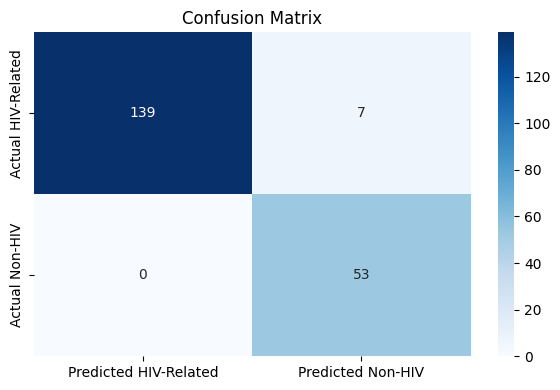


Classification Report:
              precision    recall  f1-score   support

 HIV-Related       1.00      0.95      0.98       146
     Non-HIV       0.88      1.00      0.94        53

    accuracy                           0.96       199
   macro avg       0.94      0.98      0.96       199
weighted avg       0.97      0.96      0.97       199



In [15]:
# Create a boolean mask for the actual and predicted labels
lables = df['label'].to_numpy()
y_true = np.where(lables == 'non HIV', 'Non HIV', 'HIV Related')
prompt_array = df['if_sti_avg'].to_numpy()
y_pred = np.where((prompt_array == 'No') | (prompt_array == 'Unsure'), 'Non HIV', 'HIV Related')
labels = ['HIV-Related' , 'Non-HIV']

# call function to print confusion matrix
print_confusion_matrix(y_true, y_pred, labels)

**Drop the non_HIV tweets**

In [16]:
# df_hiv = df[df['label'] != 'non HIV']
# df = df_hiv.copy()

**Actionable vetted and actionable tweets agains inst_sti (4,5 and 7) prompts:**

In [17]:
df['inst3_any_avg'].value_counts()

inst3_any_avg
No     148
Yes     51
Name: count, dtype: int64

Confusion Matrix:
                       Predicted Actionable  Predicted Not_actionable
Actual Actionable                        37                        11
Actual Not_actionable                    14                       137


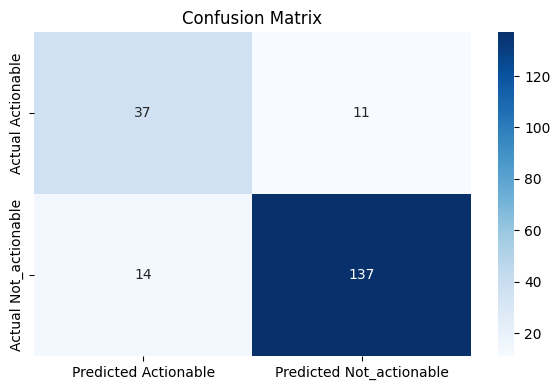


Classification Report:
                precision    recall  f1-score   support

    Actionable       0.73      0.77      0.75        48
Not_actionable       0.93      0.91      0.92       151

      accuracy                           0.87       199
     macro avg       0.83      0.84      0.83       199
  weighted avg       0.88      0.87      0.88       199



In [18]:
# Create a boolean mask for the actual and predicted labels
lables = df['label'].to_numpy()
y_true = np.where(((lables == 'actionable vetted') | (lables == 'actionable')) , 'Actionable', 'Not_actionable')
# y_true
prompt_array = df['inst3_any_avg'].to_numpy()
y_pred = np.where((prompt_array == 'Yes'), 'Actionable', 'Not_actionable')
labels = ['Actionable', 'Not_actionable']

# call function to print confusion matrix
print_confusion_matrix(y_true, y_pred, labels)

**Random HIV tweets agains random_hiv_avg:**

In [19]:
df['random_hiv_avg'].value_counts()

random_hiv_avg
No     136
Yes     63
Name: count, dtype: int64

In [20]:
df['label'].value_counts()

label
negative messages    74
non HIV              53
actionable vetted    24
actionable           24
random hiv           24
Name: count, dtype: int64

In [21]:
# df_hiv = df[df['label'] != 'non HIV']
# df = df_hiv.copy()

Confusion Matrix:
                   Predicted Non_Random  Predicted Random HIV
Actual Non_Random                   125                    50
Actual Random HIV                    11                    13


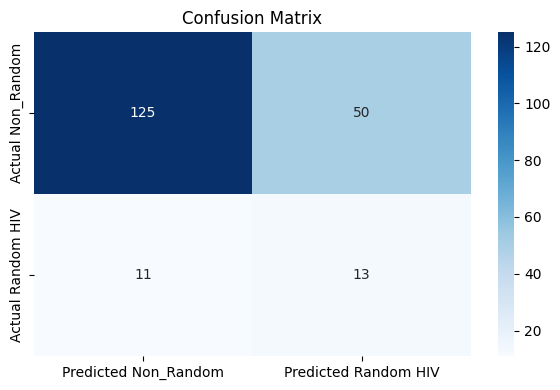


Classification Report:
              precision    recall  f1-score   support

  Non_Random       0.92      0.71      0.80       175
  Random HIV       0.21      0.54      0.30        24

    accuracy                           0.69       199
   macro avg       0.56      0.63      0.55       199
weighted avg       0.83      0.69      0.74       199



In [22]:
# Create a boolean mask for the actual and predicted labels
lables = df['label'].to_numpy()
y_true = np.where((lables == 'random hiv'), 'Random HIV', 'Non_Random')
# y_true
prompt_array = df['random_hiv_avg'].to_numpy()
y_pred = np.where((prompt_array == 'Yes'), 'Random HIV', 'Non_Random')
labels = [ 'Non_Random' , 'Random HIV']

# call function to print confusion matrix
print_confusion_matrix(y_true, y_pred, labels)

In [46]:
random_df = df[(df['random_hiv_avg'] == 'Yes') & (df['label'] != 'random hiv') ].copy()
random_df = random_df[['Content', 'label', 'negt_any_avg', 'inst3_any_avg', 'random_hiv_avg']]
pd.set_option('display.max_colwidth', None)
# Display all rows
random_df['label'].value_counts()

label
negative messages    41
actionable            8
actionable vetted     1
Name: count, dtype: int64

**Tweets with actionable label that ChatGPT find them Random HIV**

In [43]:
random_df = df[(df['random_hiv_avg'] == 'Yes') & (df['label'] == 'actionable')].copy()
random_df = random_df[['Content']]
pd.set_option('display.max_colwidth', None)
# Display tweets wth "actionable" label that Chat GPT found Random
random_df

,Content
29,@lovekrieee A doctor wrote in his medical chart/ record that he was HIV+ without ever testing him. Found out he wasn't and wants to sue.
34,@SwingerUPodcast That’s one thing that’s always baffled me when people tell me how they manage sti/std risk: “Oh I get tested every couple months or so”. Wait what?!
36,"human immune deficiency virus (HIV) and hepatitis C virus, already are available as commercial kits.\n4. Quality assessment and proficiency #testing programs still are evolving. DNA tests in oncology, such as T- and B-cell gene rearrangements and t(9;22) translocation,..."
37,The same people that say they wouldn’t date someone with HIV are the same gworls that haven’t been tested in years or haven’t been tested AT ALL!
38,@kneezurr 😭😭😭😭 not even an actual factual HIV test self
39,The impacts of depression and anxiety on quality of life among patients with HIV/AIDS and their spouses: testing dyadic dynamics using the actor-partner interdependence model https://t.co/paeDlcyJgl
41,"@AduAndante Fortunately or unfortunately, the mouth has no protection made for it like condoms and so on. So the only way out is abstinence."
43,we've already discussed there's still a risk just cuz u take medication all it takes is for u to forget &amp; that's easy to do it's a reason birth control isn't 100% also condoms aren't 100% something could go wrong at any point So those people have the right not to risk that


In [49]:
non_random_df = df[(df['random_hiv_avg'] == 'No') & (df['label'] == 'random hiv')].copy()
non_random_df = non_random_df[['Content']]
pd.set_option('display.max_colwidth', None)
# Display tweets wth "actionable" label that Chat GPT found Random
non_random_df

,Content
175,"Infections like gonorrhea and syphilis can tamper with your fertility. Condom is cheap, inability to reproduce is expensive."
176,@balegdeh34 @BoriboyXx Yeah but if you’re worried about hiv (the beginning part of aids) you can go on prep and/or use condoms. And I think they can give you something if you think you recently got HIV (not aids)
180,Start wearing condoms bc you never know or making the first date the clinic so y’all can be checked together going forward… As far as the herpes it lives in your body forever so all you can do is manage it and not have sex when it’s flared or you’ll pass it
181,RT if you wanna fuck my whore mom #incest #incestmom #bareback #nocondom #taboo #cuck #cuckold #cuckson #rawislaw #discord #std #sti #nolimits #poz #pozslut #pozwhore #bbw #slut #whore #creampie #freeuse #lotlizard #milf #qos #bbc #hooker #prostitute https://t.co/tiYMLAPlOF
184,What if in the 80s we treated HIV/AIDS the same way we are treating #COVID19 now. \nPublic Health Official: \nNo need to wear a condom we don’t want to upset anyone or remind them that AIDS is still around. In any case condoms don’t work😱\n#COVIDisAirborne \n#CovidIsNotOver
189,Most insurances will actually cover testing every 3 months and theres places like https://t.co/duh82Pgytm that you can pay out of pocket and get tests for at your own discretion. Once a year/6months if you out here and worried about it is crazy behavior lol
190,"@Diegochuene For you was best because he can't read, slept with an HIV activist woman without using condoms and when world media ask him what he did after sleeping with the he said he took a shower.What a stupid president, illetirate we ever had."
192,"One main feature of the AwraSafely app is the HIV Testing Request where clients will have access to different HIV testing modalities namely community-based screening, facility-based testing and HIV self-testing.\n\nhttps://t.co/5lvzyuYQz9\n\n#ExplainExplainExplain https://t.co/BLmwy7Bq4v"
193,Kause them the ones running to tuta with hiv saying tuta wat u need that condom for
194,"Whatever you're doing to stop HIV whether it's regularly test, or you're treating, preventing with PrEP or condom, you're a treatment supporter to PLHIV or referring friends to treatment or prevention or educating people, or fighting stigma, is appreciated. Everyone is important."


**Negative messages tweets agains negt_any_avg prompts:**

In [24]:
merged_df = neg_df.merge(df, on='Content', how='inner')
merged_df.loc[merged_df['neg_revisit'] == 'No', 'label'] = 'non negative'

In [25]:
merged_df['label'].value_counts()

label
negative messages    38
non negative         36
Name: count, dtype: int64

In [26]:
merged_df['neg_revisit'].value_counts()

neg_revisit
Yes    38
No     36
Name: count, dtype: int64

In [27]:
merged_df['negt_any_avg'].value_counts()

negt_any_avg
Yes    44
No     30
Name: count, dtype: int64

Confusion Matrix:
                             Predicted Non_negative Tweet  \
Actual Non_negative Tweet                              25   
Actual Truly Negative Tweet                             5   

                             Predicted Truly Negative Tweet  
Actual Non_negative Tweet                                11  
Actual Truly Negative Tweet                              33  


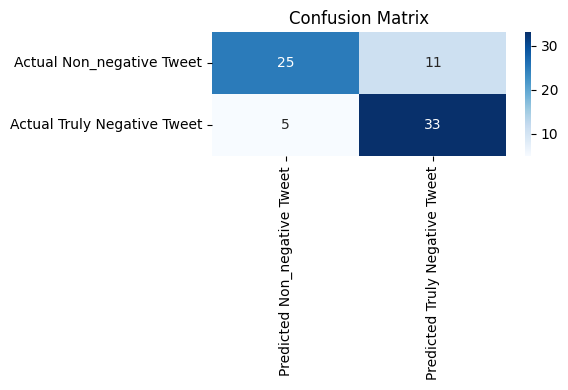


Classification Report:
                      precision    recall  f1-score   support

  Non_negative Tweet       0.83      0.69      0.76        36
Truly Negative Tweet       0.75      0.87      0.80        38

            accuracy                           0.78        74
           macro avg       0.79      0.78      0.78        74
        weighted avg       0.79      0.78      0.78        74



In [28]:
# Create a boolean mask for the actual and predicted labels
lables = merged_df['label'].to_numpy()
y_true = np.where((lables == 'negative messages') , 'Truly Negative Tweet', 'Non_negative Tweet')

propmt_array = merged_df['negt_any_avg'].to_numpy()
y_pred = np.where((propmt_array == 'Yes'), 'Truly Negative Tweet', 'Non_negative Tweet')
labels = [ 'Non_negative Tweet' , 'Truly Negative Tweet',]

# call function to print confusion matrix
print_confusion_matrix(y_true, y_pred, labels)

**Check for tweets that ChatGPT annotated as both negative and actionable simultaneously:**

In [51]:
df['neg_actionable'] = 'No'
df.loc[((df['negt_any_avg'] == 'Yes') &
        (df['inst3_any_avg'] == 'Yes')), 'neg_actionable'] = 'Yes'

df['neg_actionable'].value_counts() 

neg_actionable
No     194
Yes      5
Name: count, dtype: int64

In [52]:
# merged_df = neg_df.merge(df, on='Content', how='inner')
# merged_df.loc[merged_df['neg_revisit'] == 'No', 'label'] = 'non negative'

In [50]:
neg_act_df = df[df['neg_actionable'] == 'Yes'].copy()
neg_act_df = neg_act_df[['Content', 'label', 'negt_any_avg', 'inst3_any_avg', 'neg_actionable']]
neg_act_df

,Content,label,negt_any_avg,inst3_any_avg,neg_actionable
19,This is with any std. It irritates me hearing people say they don’t get tested or they know they’re good. Like no you don’t know you’re good. You get tested after every partner or periodically even if you’re in a relationship ‼️,actionable vetted,Yes,Yes,Yes
26,"@MoishyleezKevin Free condoms are to control population and spread of HIV/AIDS and other sexually transmitted diseases. \nRubber is not expensive to produce unlike sanitary pads, which begs the questions, who'll foot the production cost?",actionable,Yes,Yes,Yes
33,Like I can easily do an at home HIV test but everything else?,actionable,Yes,Yes,Yes
44,"@STORMYSUMMERS_ Condoms definitely suck, but I’m still gonna use ‘em when I’m not fluid bonded to someone.",actionable,Yes,Yes,Yes
189,Most insurances will actually cover testing every 3 months and theres places like https://t.co/duh82Pgytm that you can pay out of pocket and get tests for at your own discretion. Once a year/6months if you out here and worried about it is crazy behavior lol,random hiv,Yes,Yes,Yes


**Check for Tweets Annotated as Actionable/Actionable_Vetted by Humans and Annotated as Negative by ChatGPT**

In [54]:
df['false_neg'] = 'No'
df.loc[(((df['label'] == 'actionable vetted') | 
        (df['label'] == 'actionable')) &
        (df['negt_any_avg'] == 'Yes')), 'false_neg'] = 'Yes'

df['false_neg'].value_counts() 


false_neg
No     188
Yes     11
Name: count, dtype: int64

In [55]:
check_df = df[df['false_neg'] == 'Yes'].copy()
check_df = check_df[['Content', 'label', 'negt_any_avg', 'inst3_any_avg', 'false_neg']]
check_df

,Content,label,negt_any_avg,inst3_any_avg,false_neg
19,This is with any std. It irritates me hearing people say they don’t get tested or they know they’re good. Like no you don’t know you’re good. You get tested after every partner or periodically even if you’re in a relationship ‼️,actionable vetted,Yes,Yes,Yes
26,"@MoishyleezKevin Free condoms are to control population and spread of HIV/AIDS and other sexually transmitted diseases. \nRubber is not expensive to produce unlike sanitary pads, which begs the questions, who'll foot the production cost?",actionable,Yes,Yes,Yes
29,@lovekrieee A doctor wrote in his medical chart/ record that he was HIV+ without ever testing him. Found out he wasn't and wants to sue.,actionable,Yes,No,Yes
33,Like I can easily do an at home HIV test but everything else?,actionable,Yes,Yes,Yes
34,@SwingerUPodcast That’s one thing that’s always baffled me when people tell me how they manage sti/std risk: “Oh I get tested every couple months or so”. Wait what?!,actionable,Yes,No,Yes
37,The same people that say they wouldn’t date someone with HIV are the same gworls that haven’t been tested in years or haven’t been tested AT ALL!,actionable,Yes,No,Yes
38,@kneezurr 😭😭😭😭 not even an actual factual HIV test self,actionable,Yes,No,Yes
41,"@AduAndante Fortunately or unfortunately, the mouth has no protection made for it like condoms and so on. So the only way out is abstinence.",actionable,Yes,No,Yes
43,we've already discussed there's still a risk just cuz u take medication all it takes is for u to forget &amp; that's easy to do it's a reason birth control isn't 100% also condoms aren't 100% something could go wrong at any point So those people have the right not to risk that,actionable,Yes,No,Yes
44,"@STORMYSUMMERS_ Condoms definitely suck, but I’m still gonna use ‘em when I’m not fluid bonded to someone.",actionable,Yes,Yes,Yes


In [ ]:
**Check for tweets that ChatGPT annotated as both negative and actionable simultaneously:**